# Análises de dados

### Bibliotecas e funções

In [1]:
!pip install igraph
!pip install leidenalg


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import igraph as ig
import pandas as pd
import json
import random
import helper_functions as hf
from detect_and_plot_leiden import detect_and_plot

c:\Users\pedro\Documents\Github\Trabalho_Final-Ciencia_de_Redes\helper_functions.py:201: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  \gamma$ (por exemplo (2.0, 3.0)).


In [2]:
hu_data = hf.prepare_data("HU")
hr_data = hf.prepare_data("HR")
ro_data = hf.prepare_data("RO")
partitions_hu = detect_and_plot(hu_data, resolution=1.0, plot=False, seed=1042)
partitions_hr = detect_and_plot(hr_data, resolution=1.0, plot=False, seed=1042)
partitions_ro = detect_and_plot(ro_data, resolution=1.0, plot=False, seed=1042)

Grafo criado com 47538 nós e 222887 arestas
Grafo criado com 54573 nós e 498202 arestas
Grafo criado com 41773 nós e 125826 arestas
Found 27 communities.
Found 25 communities.
Found 50 communities.
Grafo criado com 41773 nós e 125826 arestas
Found 27 communities.
Found 25 communities.
Found 50 communities.


### 1. Quais comunidades mais se comunicam e quais estilos musicais que cada uma escuta?

In [3]:
def community_top_songs(partitions, graph):
    top_songs = hf.get_top_songs_by_community(partitions, graph=graph, song_attr='tracks', top_n=5)
    for comm, items in top_songs.items():
        print(f"Community {comm}:")
        for item, count in items:
            print(f"  {item} -> {count}")


# community_top_songs(partitions_hu, hu_data)
# community_top_songs(partitions_hr, hr_data)
# community_top_songs(partitions_ro, ro_data)
print(f"Hungria: {hf.get_top_songs_by_community(partitions=partitions_hu, graph=hu_data)}")
print(f"Croácia: {hf.get_top_songs_by_community(partitions=partitions_hr, graph=hr_data)}")
print(f"Romênia: {hf.get_top_songs_by_community(partitions=partitions_ro, graph=ro_data)}")

Hungria: {5: [('Pop', 1696), ('Dance', 1187), ('Rap/Hip Hop', 1112), ('Rock', 915), ('Electro', 863)], 8: [('Pop', 1468), ('Dance', 964), ('Rap/Hip Hop', 876), ('Rock', 816), ('Electro', 713)], 20: [('Pop', 968), ('Dance', 655), ('Rap/Hip Hop', 587), ('Rock', 514), ('Electro', 490)], 0: [('Pop', 4885), ('Dance', 3414), ('Rap/Hip Hop', 3272), ('Rock', 2699), ('Electro', 2542)], 18: [('Pop', 1037), ('Dance', 693), ('Rap/Hip Hop', 629), ('Rock', 572), ('Electro', 487)], 4: [('Pop', 1928), ('Dance', 1302), ('Rap/Hip Hop', 1172), ('Rock', 1100), ('Electro', 889)], 22: [('Pop', 716), ('Dance', 487), ('Rap/Hip Hop', 432), ('Rock', 389), ('Electro', 347)], 3: [('Pop', 2316), ('Dance', 1552), ('Rap/Hip Hop', 1453), ('Rock', 1155), ('Electro', 1115)], 15: [('Pop', 1143), ('Dance', 703), ('Rap/Hip Hop', 673), ('Rock', 629), ('Electro', 532)], 1: [('Pop', 3596), ('Rock', 2500), ('Dance', 2222), ('Alternative', 2008), ('Electro', 1826)], 14: [('Pop', 1170), ('Dance', 790), ('Rap/Hip Hop', 711), ('E

### 2. Música que cada país mais escuta

In [4]:
# print(sorted(hf.get_genre_distribution(graph).values()))
# print(hf.get_genre_distribution(graph))
print(f"Hungria: {hf.get_genre_distribution(hu_data, percentage=True)}")
print(f"Croácia: {hf.get_genre_distribution(hr_data, percentage=True)}")
print(f"Romênia: {hf.get_genre_distribution(ro_data, percentage=True)}")

Hungria: {'Pop': 79.7, 'Dance': 53.01, 'Rap/Hip Hop': 47.85, 'Rock': 44.24, 'Electro': 39.17, 'Alternative': 36.99, 'R&B': 29.09, 'International Pop': 23.42, 'Techno/House': 21.42, 'Indie Rock': 19.9, 'Films/Games': 18.68, 'Film Scores': 17.34, 'Metal': 13.42, 'Contemporary R&B': 13.16, 'Indie Pop': 12.45, 'Dancefloor': 12.35, 'Singer & Songwriter': 11.01, 'Indie Pop/Folk': 10.85, 'Latin Music': 8.69, 'Disco': 8.04, 'Hard Rock': 7.92, 'Indie Rock/Rock pop': 6.66, 'Reggae': 5.73, 'Jazz': 4.47, 'East Coast': 4.43, 'Kids': 4.25, 'Classical': 3.97, 'Folk': 3.89, 'Rock & Roll/Rockabilly': 3.35, 'Blues': 3.21, 'Soul & Funk': 3.07, 'Country': 2.64, 'Dubstep': 2.39, 'Comedy': 2.37, 'Trance': 2.29, 'Chill Out/Trip-Hop/Lounge': 1.9, 'Dancehall/Ragga': 1.85, 'Contemporary Soul': 1.76, 'Dirty South': 1.62, 'Soundtracks': 1.33, 'Spirituality & Religion': 1.29, 'Musicals': 0.9, 'Asian Music': 0.79, 'Electro Pop/Electro Rock': 0.72, 'Vocal jazz': 0.69, 'Instrumental jazz': 0.64, 'TV Soundtracks': 0.6

### 3. As redes são de livre-escala ou pequeno mundo?

In [6]:
hu_scale_free = hf.is_scale_free(hu_data, return_details=True)
hr_scale_free = hf.is_scale_free(hr_data, return_details=True)
ro_scale_free = hf.is_scale_free(ro_data, return_details=True)

small_world_hu = hf.is_small_world(hu_data)
small_world_hr = hf.is_small_world(hr_data)
small_world_ro = hf.is_small_world(ro_data)

print(f"Hungria details: \n   Is scale free = {hu_scale_free['is_scale_free']}\n   Gamma = {round(hu_scale_free['gamma'], 2)}\n   Is small world? Ratio to test = {round(small_world_hu, 2)}\n")
print(f"Croácia details: \n   Is scale free = {hr_scale_free['is_scale_free']}\n   Gamma = {round(hr_scale_free['gamma'], 2)}\n   Is small world? Ratio to test = {round(small_world_hr, 2)}\n")
print(f"Romênia details: \n   Is scale free = {ro_scale_free['is_scale_free']}\n   Gamma = {round(ro_scale_free['gamma'], 2)}\n   Is small world? Ratio to test = {round(small_world_ro, 2)}\n")

Hungria details: 
   Is scale free = True
   Gamma = 2.73
   Is small world? Ratio to test = 0.5

Croácia details: 
   Is scale free = True
   Gamma = 2.39
   Is small world? Ratio to test = 0.41

Romênia details: 
   Is scale free = True
   Gamma = 2.79
   Is small world? Ratio to test = 0.6



### 4. Análise de Influência Musical: Nós Centrais vs Periféricos

In [5]:
# Analisa influência musical: nós centrais têm gosto mais diverso?
print("=" * 60)
print("ANÁLISE DE INFLUÊNCIA MUSICAL - RO")
print("=" * 60)

# 1. Análise de diversidade (nós centrais vs periféricos)
influence = hf.musical_influence_analysis(ro_data, centrality_measure='degree', return_details=True)
print(f"\nDiversidade de gêneros (medida por Shannon Entropy):")
print(f"  Nós centrais (top 25%):     {influence['entropy_central']:.4f}")
print(f"  Nós periféricos (bottom 25%): {influence['entropy_peripheral']:.4f}")
print(f"  Razão (central/periférico):  {influence['ratio_entropy']:.4f}")
print(f"  Nós centrais: {influence['n_central_nodes']}, Nós periféricos: {influence['n_peripheral_nodes']}")

# 2. Similaridade entre nós periféricos e vizinhos centrais
similarity = hf.check_neighbor_similarity(ro_data, percentile_low=25, 
                                         similarity_metric='cosine', 
                                         return_details=True)
print(f"\nSimilaridade musical entre nós periféricos e vizinhos centrais:")
print(f"  Métrica: Cosine Similarity")
print(f"  Similaridade média: {similarity['avg_similarity']:.4f} ± {similarity['std_similarity']:.4f}")
print(f"  Nós periféricos com vizinhos centrais: {similarity['n_edges_periph_to_central']} conexões\n\n")

print("=" * 60)
print("ANÁLISE DE INFLUÊNCIA MUSICAL - HR")
print("=" * 60)

# 1. Análise de diversidade (nós centrais vs periféricos)
influence = hf.musical_influence_analysis(hr_data, centrality_measure='degree', return_details=True)
print(f"\nDiversidade de gêneros (medida por Shannon Entropy):")
print(f"  Nós centrais (top 25%):     {influence['entropy_central']:.4f}")
print(f"  Nós periféricos (bottom 25%): {influence['entropy_peripheral']:.4f}")
print(f"  Razão (central/periférico):  {influence['ratio_entropy']:.4f}")
print(f"  Nós centrais: {influence['n_central_nodes']}, Nós periféricos: {influence['n_peripheral_nodes']}")

# 2. Similaridade entre nós periféricos e vizinhos centrais
similarity = hf.check_neighbor_similarity(hr_data, percentile_low=25, 
                                         similarity_metric='cosine', 
                                         return_details=True)
print(f"\nSimilaridade musical entre nós periféricos e vizinhos centrais:")
print(f"  Métrica: Cosine Similarity")
print(f"  Similaridade média: {similarity['avg_similarity']:.4f} ± {similarity['std_similarity']:.4f}")
print(f"  Nós periféricos com vizinhos centrais: {similarity['n_edges_periph_to_central']} conexões\n\n")

print("=" * 60)
print("ANÁLISE DE INFLUÊNCIA MUSICAL - HU")
print("=" * 60)

# 1. Análise de diversidade (nós centrais vs periféricos)
influence = hf.musical_influence_analysis(hu_data, centrality_measure='degree', return_details=True)
print(f"\nDiversidade de gêneros (medida por Shannon Entropy):")
print(f"  Nós centrais (top 25%):     {influence['entropy_central']:.4f}")
print(f"  Nós periféricos (bottom 25%): {influence['entropy_peripheral']:.4f}")
print(f"  Razão (central/periférico):  {influence['ratio_entropy']:.4f}")
print(f"  Nós centrais: {influence['n_central_nodes']}, Nós periféricos: {influence['n_peripheral_nodes']}")

# 2. Similaridade entre nós periféricos e vizinhos centrais
similarity = hf.check_neighbor_similarity(hu_data, percentile_low=25, 
                                         similarity_metric='cosine', 
                                         return_details=True)
print(f"\nSimilaridade musical entre nós periféricos e vizinhos centrais:")
print(f"  Métrica: Cosine Similarity")
print(f"  Similaridade média: {similarity['avg_similarity']:.4f} ± {similarity['std_similarity']:.4f}")
print(f"  Nós periféricos com vizinhos centrais: {similarity['n_edges_periph_to_central']} conexões")

print(f"\nInterpretação:")
print(f"  - Se razão (central/periférico) > 1: nós centrais têm gosto mais diverso")
print(f"  - Se similaridade alta (> 0.5): periféricos tendem a ouvir o que os centrais ouvem")

ANÁLISE DE INFLUÊNCIA MUSICAL - RO

Diversidade de gêneros (medida por Shannon Entropy):
  Nós centrais (top 25%):     3.2921
  Nós periféricos (bottom 25%): 3.3041
  Razão (central/periférico):  0.9964
  Nós centrais: 11459, Nós periféricos: 11062

Similaridade musical entre nós periféricos e vizinhos centrais:
  Métrica: Cosine Similarity
  Similaridade média: 0.3662 ± 0.2380
  Nós periféricos com vizinhos centrais: 14102 conexões


ANÁLISE DE INFLUÊNCIA MUSICAL - HR

Diversidade de gêneros (medida por Shannon Entropy):
  Nós centrais (top 25%):     3.2351
  Nós periféricos (bottom 25%): 3.2860
  Razão (central/periférico):  0.9845
  Nós centrais: 13854, Nós periféricos: 15370

Diversidade de gêneros (medida por Shannon Entropy):
  Nós centrais (top 25%):     3.2351
  Nós periféricos (bottom 25%): 3.2860
  Razão (central/periférico):  0.9845
  Nós centrais: 13854, Nós periféricos: 15370

Similaridade musical entre nós periféricos e vizinhos centrais:
  Métrica: Cosine Similarity
  Si

### 5. Distribuição de Graus e Lei de Potência

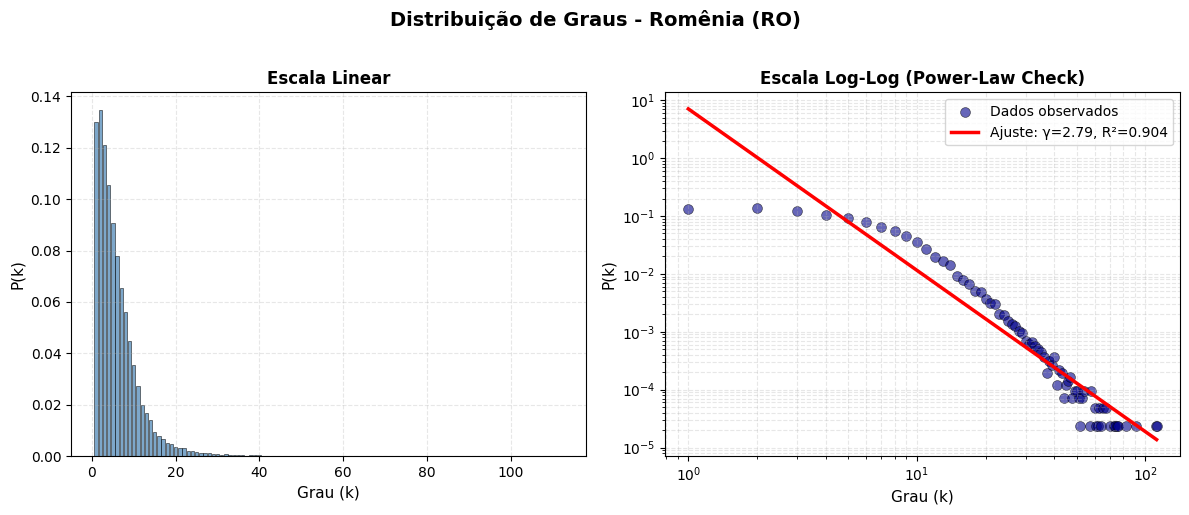

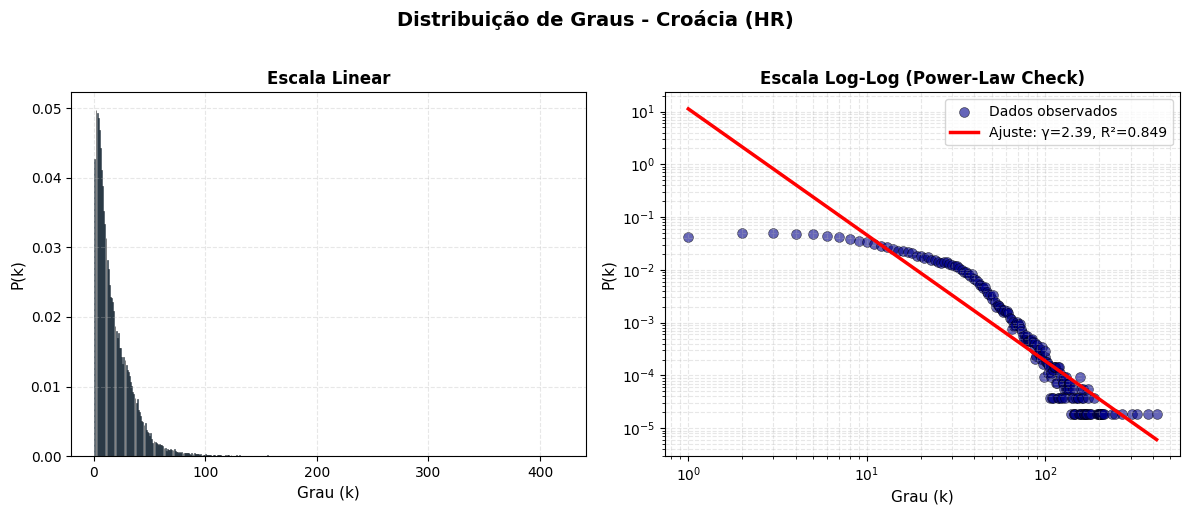

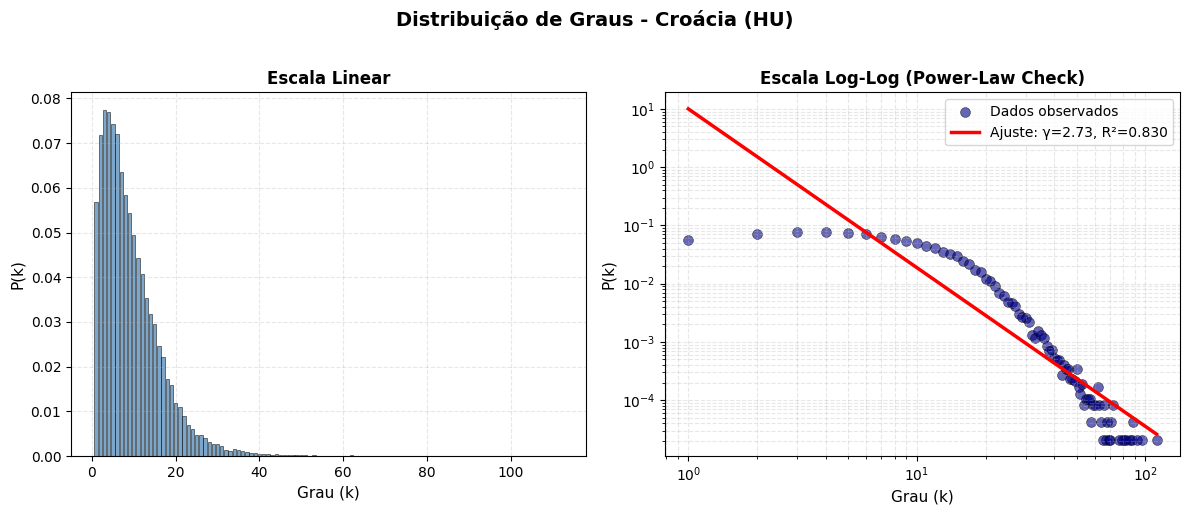

In [8]:
# Plota distribuição de graus para RO
hf.plot_degree_distribution(ro_data, title="Distribuição de Graus - Romênia (RO)", 
                             show_fit=True, output_path=None)

# Plota para HR
hf.plot_degree_distribution(hr_data, title="Distribuição de Graus - Croácia (HR)", 
                             show_fit=True, output_path=None)

# Plota para HU
hf.plot_degree_distribution(hu_data, title="Distribuição de Graus - Croácia (HU)", 
                             show_fit=True, output_path=None)

### 6. Avaliação da Qualidade das Comunidades

In [6]:
# Avalia qualidade das comunidades detectadas
quality_ro = hf.evaluate_community_quality(ro_data, partitions_ro, return_details=True)
quality_hr = hf.evaluate_community_quality(hr_data, partitions_hr, return_details=True)
quality_hu = hf.evaluate_community_quality(hu_data, partitions_hu, return_details=True)

print("=" * 70)
print("QUALIDADE DAS COMUNIDADES")
print("=" * 70)

for country, quality in [("RO", quality_ro), ("HR", quality_hr), ("HU", quality_hu)]:
    print(f"\n{country}:")
    print(f"  Modularidade:              {quality['modularity']:.4f}")
    print(f"  Nº de comunidades:         {quality['n_communities']}")
    print(f"  Densidade interna média:   {quality['internal_density_avg']:.4f}")
    print(f"  Condutância média:         {quality['conductance_avg']:.4f}")
    print(f"  Score de qualidade (0-1):  {quality['quality_score']:.4f}")
    print(f"  Tamanho de comunidades:")
    print(f"    - Min: {quality['community_sizes']['min']}, Max: {quality['community_sizes']['max']}")
    print(f"    - Média: {quality['community_sizes']['mean']:.1f}, Mediana: {quality['community_sizes']['median']:.1f}")

QUALIDADE DAS COMUNIDADES

RO:
  Modularidade:              0.7627
  Nº de comunidades:         50
  Densidade interna média:   0.0808
  Condutância média:         0.1849
  Score de qualidade (0-1):  0.5686
  Tamanho de comunidades:
    - Min: 4, Max: 6019
    - Média: 835.5, Mediana: 689.0

HR:
  Modularidade:              0.7412
  Nº de comunidades:         25
  Densidade interna média:   0.0896
  Condutância média:         0.1903
  Score de qualidade (0-1):  0.5594
  Tamanho de comunidades:
    - Min: 3, Max: 9879
    - Média: 2182.9, Mediana: 1624.0

HU:
  Modularidade:              0.6984
  Nº de comunidades:         27
  Densidade interna média:   0.0062
  Condutância média:         0.2625
  Score de qualidade (0-1):  0.4986
  Tamanho de comunidades:
    - Min: 155, Max: 6021
    - Média: 1760.7, Mediana: 1476.0


### 7. Comunicação Inter-Comunitária e Influência de Gêneros Musicais

ANÁLISE DE COMUNICAÇÃO INTER-COMUNITÁRIA - ROMÊNIA (RO)

Arestas inter-comunitárias: 24130
Arestas intra-comunitárias: 101696
Proporção inter/total: 0.1918

Conectividade das comunidades (quantas outras se conectam):
  Comunidade 0: 49 vizinhas
  Comunidade 1: 41 vizinhas
  Comunidade 2: 40 vizinhas
  Comunidade 3: 40 vizinhas
  Comunidade 4: 39 vizinhas
  Comunidade 5: 39 vizinhas
  Comunidade 6: 40 vizinhas
  Comunidade 7: 40 vizinhas
  Comunidade 8: 40 vizinhas
  Comunidade 9: 40 vizinhas
  Comunidade 10: 40 vizinhas
  Comunidade 11: 40 vizinhas
  Comunidade 12: 40 vizinhas
  Comunidade 13: 40 vizinhas
  Comunidade 14: 40 vizinhas
  Comunidade 15: 40 vizinhas
  Comunidade 16: 40 vizinhas
  Comunidade 17: 40 vizinhas
  Comunidade 18: 40 vizinhas
  Comunidade 19: 40 vizinhas
  Comunidade 20: 38 vizinhas
  Comunidade 21: 39 vizinhas
  Comunidade 22: 40 vizinhas
  Comunidade 23: 39 vizinhas
  Comunidade 24: 39 vizinhas
  Comunidade 25: 39 vizinhas
  Comunidade 26: 39 vizinhas
  Comunida

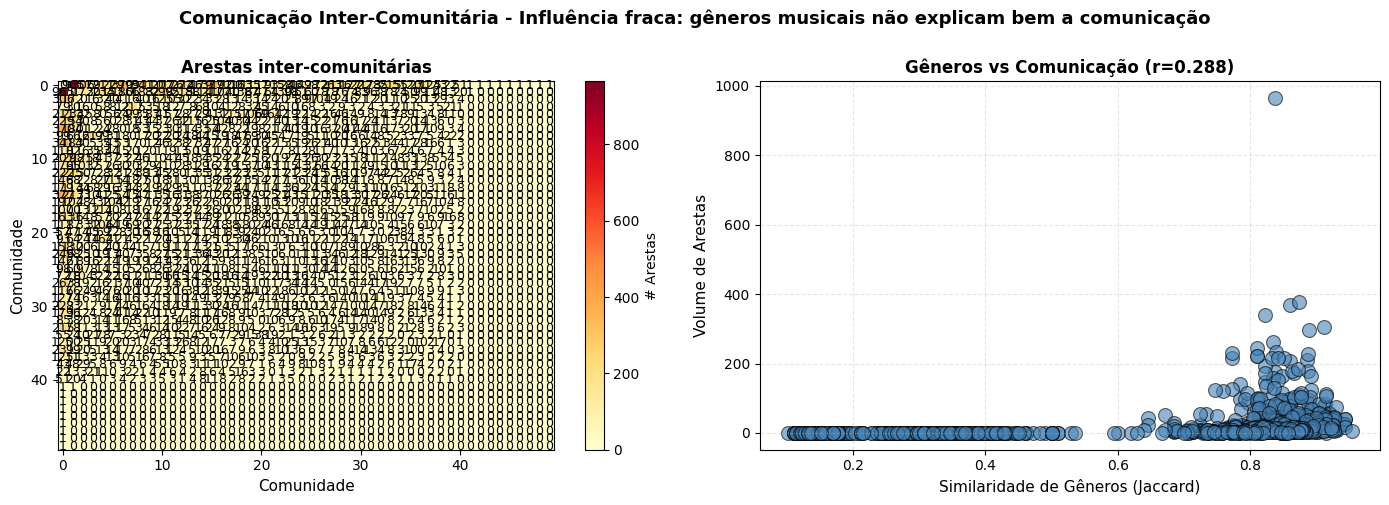

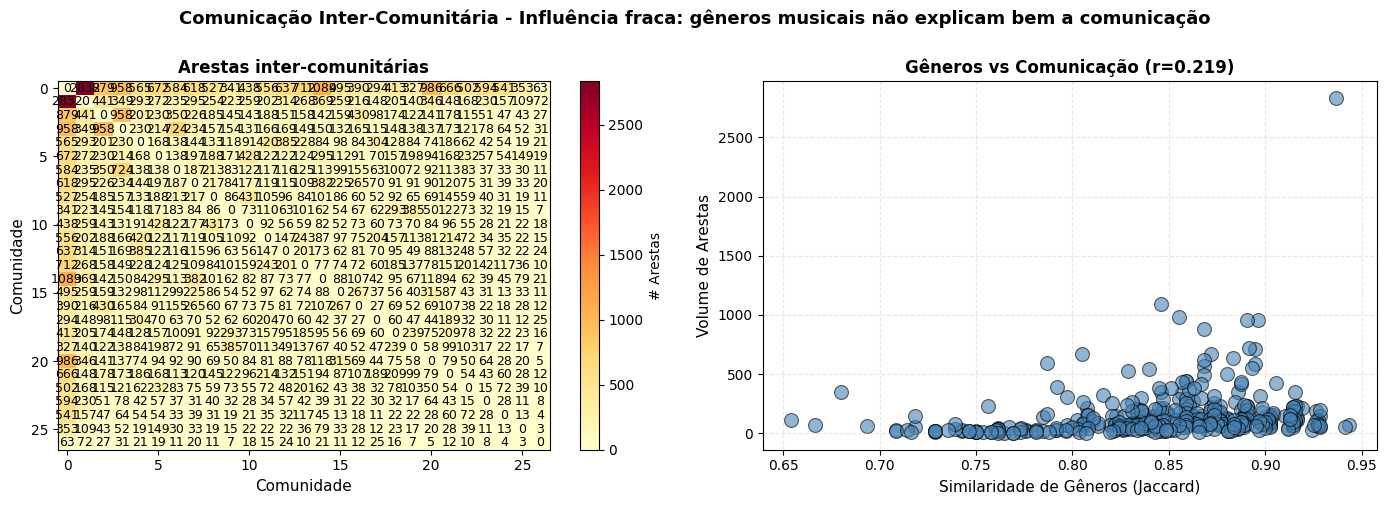

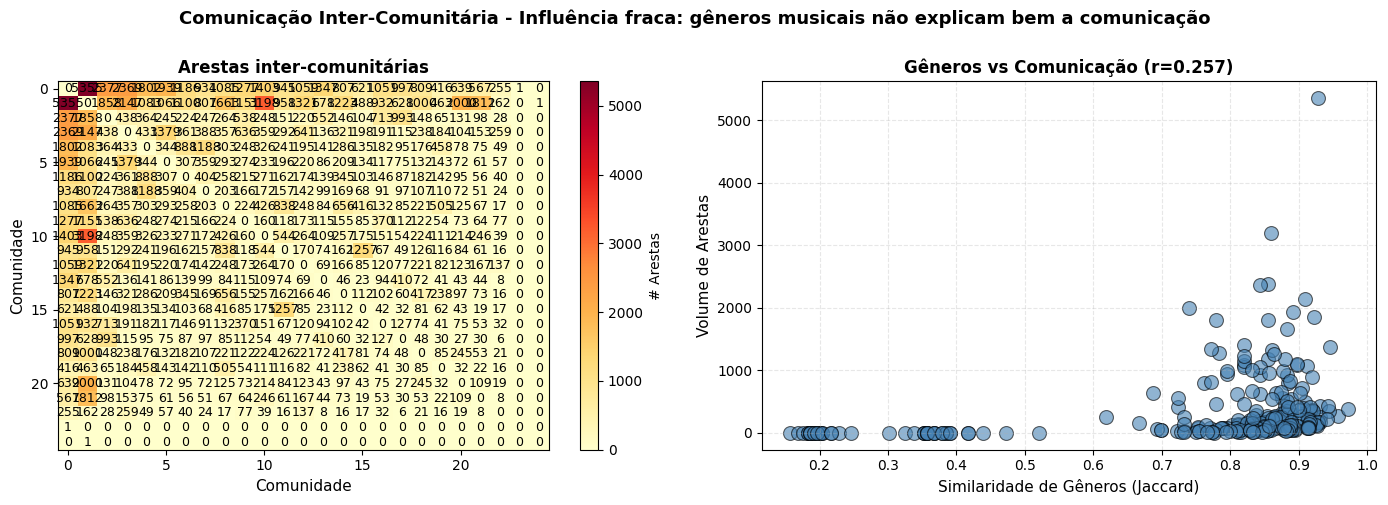

In [10]:
# Analisa comunicação inter-comunitária para RO
print("=" * 70)
print("ANÁLISE DE COMUNICAÇÃO INTER-COMUNITÁRIA - ROMÊNIA (RO)")
print("=" * 70)

comm_analysis_ro = hf.analyze_inter_community_communication(ro_data, partitions_ro, return_details=True)
print(f"\nArestas inter-comunitárias: {comm_analysis_ro['total_inter_edges']}")
print(f"Arestas intra-comunitárias: {comm_analysis_ro['total_intra_edges']}")
print(f"Proporção inter/total: {comm_analysis_ro['edge_ratio']:.4f}")
print(f"\nConectividade das comunidades (quantas outras se conectam):")
for c, conn in enumerate(comm_analysis_ro['community_connectivity']):
    print(f"  Comunidade {c}: {conn} vizinhas")

# Analisa influência de gêneros musicais na comunicação
print("\n" + "=" * 70)
print("INFLUÊNCIA DE GÊNEROS MUSICAIS NA COMUNICAÇÃO - RO")
print("=" * 70)

genre_analysis_ro = hf.analyze_genre_influence_on_communication(ro_data, partitions_ro, return_details=True)
print(f"\nCorrelação (gêneros ↔ comunicação): {genre_analysis_ro['correlation']:.4f}")
print(f"Parecer: {genre_analysis_ro['analysis']}")
print(f"\nDiversidade de gêneros por comunidade (Shannon Entropy):")
for c, diversity in enumerate(genre_analysis_ro['genre_diversity_per_community']):
    print(f"  Comunidade {c}: {diversity:.4f}")

# ===========================================================================================================
# Analisa comunicação inter-comunitária para HU
print("=" * 70)
print("ANÁLISE DE COMUNICAÇÃO INTER-COMUNITÁRIA - Hungria (HU)")
print("=" * 70)

comm_analysis_hu = hf.analyze_inter_community_communication(hu_data, partitions_hu, return_details=True)
print(f"\nArestas inter-comunitárias: {comm_analysis_hu['total_inter_edges']}")
print(f"Arestas intra-comunitárias: {comm_analysis_hu['total_intra_edges']}")
print(f"Proporção inter/total: {comm_analysis_hu['edge_ratio']:.4f}")
print(f"\nConectividade das comunidades (quantas outras se conectam):")
for c, conn in enumerate(comm_analysis_hu['community_connectivity']):
    print(f"  Comunidade {c}: {conn} vizinhas")

# Analisa influência de gêneros musicais na comunicação
print("\n" + "=" * 70)
print("INFLUÊNCIA DE GÊNEROS MUSICAIS NA COMUNICAÇÃO - HU")
print("=" * 70)

genre_analysis_hu = hf.analyze_genre_influence_on_communication(hu_data, partitions_hu, return_details=True)
print(f"\nCorrelação (gêneros ↔ comunicação): {genre_analysis_hu['correlation']:.4f}")
print(f"Parecer: {genre_analysis_hu['analysis']}")
print(f"\nDiversidade de gêneros por comunidade (Shannon Entropy):")
for c, diversity in enumerate(genre_analysis_hu['genre_diversity_per_community']):
    print(f"  Comunidade {c}: {diversity:.4f}")

# ===========================================================================================================
# Analisa comunicação inter-comunitária para HR
print("=" * 70)
print("ANÁLISE DE COMUNICAÇÃO INTER-COMUNITÁRIA - Croácia (HR)")
print("=" * 70)

comm_analysis_hr = hf.analyze_inter_community_communication(hr_data, partitions_hr, return_details=True)
print(f"\nArestas inter-comunitárias: {comm_analysis_hr['total_inter_edges']}")
print(f"Arestas intra-comunitárias: {comm_analysis_hr['total_intra_edges']}")
print(f"Proporção inter/total: {comm_analysis_hr['edge_ratio']:.4f}")
print(f"\nConectividade das comunidades (quantas outras se conectam):")
for c, conn in enumerate(comm_analysis_hr['community_connectivity']):
    print(f"  Comunidade {c}: {conn} vizinhas")

# Analisa influência de gêneros musicais na comunicação
print("\n" + "=" * 70)
print("INFLUÊNCIA DE GÊNEROS MUSICAIS NA COMUNICAÇÃO - HR")
print("=" * 70)

genre_analysis_hr = hf.analyze_genre_influence_on_communication(hr_data, partitions_hr, return_details=True)
print(f"\nCorrelação (gêneros ↔ comunicação): {genre_analysis_hr['correlation']:.4f}")
print(f"Parecer: {genre_analysis_hr['analysis']}")
print(f"\nDiversidade de gêneros por comunidade (Shannon Entropy):")
for c, diversity in enumerate(genre_analysis_hr['genre_diversity_per_community']):
    print(f"  Comunidade {c}: {diversity:.4f}")

# Plota a análise
print("\nGerando gráficos...")
hf.plot_inter_community_communication(ro_data, partitions_ro)
hf.plot_inter_community_communication(hu_data, partitions_hu)
hf.plot_inter_community_communication(hr_data, partitions_hr)